# Determine if there is an enrichment of disease-associated SNPs in certain enhancer transcription types

1. Get the split enhancer types (Early, Early-plateau, Late) AND super-enhancer or not
	* This might differ based on perturbation so do based on BOTH perturbations and only one.
2. Get the frequency of each enhancer type for AllofUs SNPs (this will serve as background)
3. Get the frequency of each enhancer type for SNPs with significance in Asthma or COPD




**Important Notes:**
* SOme of the SNPs are mapped to multiple enhancers. I should consider if I count the enhancer unit as 1 or each enhancer as 1.
* I originally used strict cutoffs for early vs late, etc. Some may be a bit split (like early and nonsig Downregulation still).

In [1]:
library(data.table)
library(ggplot2)
library(stringr)

Warning message:
"package 'data.table' was built under R version 4.4.1"
Warning message:
"package 'ggplot2' was built under R version 4.4.1"
Warning message:
"package 'stringr' was built under R version 4.4.1"


### Functions

In [2]:
get_mu_list <- function(sig_list) {
	chrom_split <- str_split_fixed(sig_list, ":", 2)
	bp_split <- str_split_fixed(chrom_split[,2], "-", 2)
	mu_list <- as.numeric((as.numeric(bp_split[,1]) + as.numeric(bp_split[,2]))/2)
	final_list = paste0(chrom_split[,1], ":", mu_list)
return(final_list)
}

get_timing_sig <- function(sig_feat) {
    # up at 30min and down by 120. Not significant for 120 vs Veh
    early_rise = setdiff(intersect(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # down at 30min and up by 120. Not significant for 120 vs Veh
    early_fall = setdiff(intersect(sig_feat[["P30_vs_Veh_down"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
	early = union(early_rise, early_fall)
    # up 120min and 30min, with no change between 120 & 30min
    plat_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P30_vs_Veh_up"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # down 120min and 30min, with no change between 120 & 30min
    plat_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P30_vs_Veh_down"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
	plat = union(plat_rise, plat_fall)
    # up at 120min compared to Veh and 30min. Not sig at 30min
    late_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    # down at 120min compared to Veh and 30min. Not sig at 30min
    late_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))

	late = union(late_rise, late_fall)
    time_sig <- list("ER"=early_rise, "EF"=early_fall, "EPR"=plat_rise, "EPF"=plat_fall, 
                     "LR"=late_rise, "LF"=late_fall, "Early"=early, "Plat"=plat, "Late"=late)
    return(time_sig)
    }


get_number_SNPs <- function(sig_list, cat_name) {
	safe_n <- function(x) {
  length(unique(na.omit(x)))
}

	if (length(sig_list) == 0) {
		message(cat_name, " has no enhancers")
		dt <- as.data.frame(data.table("Enh_Category"=rep(cat_name, 7), 
	"Sig_Category"=c("Total", "COPD_sig", "Asthma_sig", "Either_sig", "Both_sig", "Both_sig_same_dir"), 
						"N"=rep(0, 7), "Ratio"=rep(0, 7), "N_Enh"=rep(0, 7)))
		return(dt)
	}
	if (length(sig_list) > 1000) {
		message("Warning sig list is long for ", cat_name)
		matched = full_collapse_rsid[grepl(full_collapse_rsid$central_fixed, pattern=paste(sig_list[1:1000], collapse="|")),]
		# split into chungs of 1000
		for (i in seq(1001, length(sig_list), by=1000)) {
			matched_chunk = full_collapse_rsid[grepl(full_collapse_rsid$central_fixed, pattern=paste(sig_list[i:min(i+999, length(sig_list))], collapse="|")),]
			matched = rbind(matched, matched_chunk)
		}
	} else {
		# cehck if any of the features are in the full_collapse_rsid list
		matched = full_collapse_rsid[grepl(full_collapse_rsid$central_fixed, pattern=paste(sig_list, collapse="|")),]
	}
	
	# get number unique rsids
	full_list_rsids = unique(matched$rsid)
	either_sig = matched[(matched$P_copd < 0.05) | (matched$P_asthma < 0.05),]
	both_sig = matched[(matched$P_copd < 0.05) & (matched$P_asthma < 0.05),]
	# get the number rsids where P_co
	dt <- as.data.frame(data.table("Enh_Category"=rep(cat_name, 7), 
	"Sig_Category"=c("Total", "COPD", "Asthma", "Either", "Either\nSame Dir", "Both", "Both\nsame_dir"), 
						"N"=c(safe_n(full_list_rsids), 
						safe_n(unique(matched[matched$P_copd < 0.05,]$rsid)), 
						safe_n(unique(matched[matched$P_asthma < 0.05,]$rsid)), 
						safe_n(unique(either_sig$rsid)), 
						safe_n(unique(either_sig[((either_sig$OR_copd > 1) & (either_sig$OR_asthma > 1)) | ((either_sig$OR_copd < 1) & (either_sig$OR_asthma < 1)),]$rsid)),
						safe_n(unique(both_sig$rsid)), 
						safe_n(unique(both_sig[((both_sig$OR_copd > 1) & (both_sig$OR_asthma > 1)) | ((both_sig$OR_copd < 1) & (both_sig$OR_asthma < 1)),]$rsid)))))
	# calculate the ratio compared to total RSIDs
	dt$Ratio = dt$N/length(full_list_rsids)
	dt$N_Enh <- length(sig_list)
	return(dt)
}


## 0. Read in enhancer types and SNPs-enhancer linkages

In [3]:
full_collapse_rsid <- readxl::read_excel("full_collapse_rsid_annotations_9.10.xlsx")
full_collapse_rsid[1:2,]
dim(full_collapse_rsid)
colnames(full_collapse_rsid)

Warning message:
"Expecting numeric in BB1063 / R1063C54: got '0.0;nan'"


CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,...,CHMM_Labels,CHMM_CellTypes,CHMM_Tissues,Gene 1 (5'),Gene 2 (3'),Nearest_Genes,NG_UPM30_L2FC(padj),NG_UPM120_L2FC(padj),NG_WSP30_L2FC(padj),NG_WSP120_L2FC(padj)
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,...,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
17,9556759,9558036,chr17:9557459,Exon,9557841,rs34354226,0.9209,0.9649,1.963e-03,...,Enh;EnhG,"BONE.OSTEO,GI.STMC.GAST,LIV.HEPG2.CNCR,STRM.CHON.MRW.DR.MSC,STRM.MRW.MSC;HRT.VENT.L","Bone,Digestive,Liver,Mesench;Heart",STX8,STX8,STX8;STX8,0.85 (1.3e-30),-0.11 (0.30),-0.03 (0.67),0.05 (0.42)
19,2015054,2017044,chr19:2016127;chr19:2015714,LIET Gene TSS Intergenic;Gene TSS Bid,2016619,rs79545373,1.1340,0.9746,5.007e-05,...,Enh;EnhG;TssA;TssAFlnk,"BLD.CD19.CPC,BLD.CD19.PPC,BLD.CD3.PPC,BLD.CD4.CD25M.IL17P.PL.TPC,BLD.CD4.CD25M.TPC,BLD.CD56.PC,BLD.GM12878,BLD.MOB.CD34.PC.F,BRN.ANT.CAUD,BRN.CING.GYR,BRN.DL.PRFRNTL.CRTX,BRN.FET.M,BRN.HIPP.MID,BRN.SUB.NIG,CRVX.HELAS3.CNCR,ESDR.H1.BMP4.TROP,ESDR.H1.MSC,FAT.ADIP.DR.MSC,FAT.ADIP.NUC,GI.DUO.SM.MUS,GI.ESO,GI.RECT.MUC.29,HRT.ATR.R,LNG.IMR90,MUS.SKLT.F,MUS.TRNK.FET,PLCNT.FET,SKIN.PEN.FRSK.KER.02,SKIN.PEN.FRSK.MEL.01,SKIN.PEN.FRSK.MEL.03,THYM.FET;IPSC.DF.19.11;GI.CLN.MUC,GI.RECT.SM.MUS,MUS.SKLT.M,SKIN.PEN.FRSK.FIB.01,SKIN.PEN.FRSK.FIB.02;BLD.DND41.CNCR,BLD.MOB.CD34.PC.M,BRST.MYO,LIV.HEPG2.CNCR","Adipose,Blood,Brain,Cervix,Digestive,ES-deriv,Epithelial,Heart,Lung,Mesench,Muscle,Other,Thymus;iPSC;Digestive,Epithelial,Muscle;Blood,Epithelial,Liver",BTBD2,LOC107985278,BTBD2;LOC107985278,-0.29 (2.8e-02);NA,-0.02 (0.93);NA,-0.88 (1.9e-44);NA,-0.69 (2.6e-28);NA


[1] 6164   69

[1] "CHR"                   "start"                 "stop"                 
 [4] "central"               "note"                  "BP"                   
 [7] "rsid"                  "OR_copd"               "OR_asthma"            
[10] "P_copd"                "P_asthma"              "meta_p_weighted"      
[13] "same_direction"        "Asthma"                "COPD"                 
[16] "Asthma OR COPD"        "Asthma AND COPD"       "central_fixed"        
[19] "UPM30_L2FC(padj)"      "UPM120_L2FC(padj)"     "WSP30_L2FC(padj)"     
[22] "WSP120_L2FC(padj)"     "Distance_to_Mu"        "TFBS_Variants"        
[25] "TFBS_TFs"              "TFBS_CellTypes"        "TFBS_Tissues"         
[28] "DA_Variants"           "DA_Traits"             "DA_Betas"             
[31] "DA_PostProbs"          "DA_Assoc_types"        "DA_PredTargets"       
[34] "DA_PTScores"           "DA_LocusSizes"         "DA_Same_variants"     
[37] "DA_Sources"            "GT_Variants"           "GTs"                  
[40] "GTs_Sources"           "GTs_Tissues"           "GTs_Same_Variants"    
[43] "GTs_Betas"             "GTs_PostProbs"         "GTs_Pvalues"          
[46] "GTs_UPM30_L2FC(padj)"  "GTs_UPM120_L2FC(padj)" "GTs_WSP30_L2FC(padj)" 
[49] "GTs_WSP120_L2FC(padj)" "ME_Variants"           "ME_EffectPreds"       
[52] "ME_EffectMeths"        "ME_AAChanges"          "ME_distFtpts"         
[55] "ME_distTSS"            "ME_PredTargets"        "ME_EffectScores"      
[58] "ME_LofteeSiftPolyphen" "CHMM_Variants"         "CHMM_Labels"          
[61] "CHMM_CellTypes"        "CHMM_Tissues"          "Gene 1 (5')"          
[64] "Gene 2 (3')"           "Nearest_Genes"         "NG_UPM30_L2FC(padj)"  
[67] "NG_UPM120_L2FC(padj)"  "NG_WSP30_L2FC(padj)"   "NG_WSP120_L2FC(padj)"

In [4]:
filt_collapse_rsid <- full_collapse_rsid[, c("CHR", "start", "stop", "central_fixed", "note", "BP", "rsid", "OR_copd", "OR_asthma",
"P_copd", "P_asthma", "UPM30_L2FC(padj)", "UPM120_L2FC(padj)", "WSP30_L2FC(padj)", "WSP120_L2FC(padj)", "Distance_to_Mu")]
filt_collapse_rsid[1:4,]

CHR,start,stop,central_fixed,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,UPM30_L2FC(padj),UPM120_L2FC(padj),WSP30_L2FC(padj),WSP120_L2FC(padj),Distance_to_Mu
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
17,9556759,9558036,chr17:9557459,Exon,9557841,rs34354226,0.9209,0.9649,1.963e-03,0.009707,-0.38 (0.51),-1.58 (1.7e-04),NA,NA,-382
19,2015054,2017044,chr19:2016127;chr19:2015714,LIET Gene TSS Intergenic;Gene TSS Bid,2016619,rs79545373,1.1340,0.9746,5.007e-05,0.136600,-2.32 (1.1e-04);NA,-0.75 (0.23);NA,-1.61 (7.5e-14);NA,-0.95 (1.5e-05);NA,-492;-905
4,5752830,5754342,chr4:5753897,Exon,5753797,rs35953626,1.1280,1.0460,1.367e-03,0.027120,0.45 (0.63),-1.4 (3.8e-02),0.3 (0.43),-1.38 (3.5e-05),100
2,88658966,88660345,chr2:88659540,Intergenic,88659568,rs10166805,1.1030,1.0290,8.412e-04,0.075560,0.2 (0.87),-0.5 (0.55),-1.52 (3.6e-04),0.15 (0.78),-28


In [5]:
# enhancers and types
## PRO-seq
ADP_nontss <- fread("../results/DESeq2/res_NonTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.txt")
ADP_nontss[1:2,]
ADP_sig_nontss <- ADP_nontss[ADP_nontss$padj < 0.01,]$V1

UPM_sig_nontss <- readRDS("../results/DESeq2/UPM_signontss_DESeq2_GeneHK_p001.rds")
WSP_sig_nontss <- readRDS("../results/DESeq2/WSP_signontss_DESeq2_GeneHK_p001.rds")

lapply(UPM_sig_nontss, length)
lapply(WSP_sig_nontss, length)
length(ADP_sig_nontss)

# get the cleaned versions
for (timing in names(UPM_sig_nontss)) {
	UPM_sig_nontss[[timing]] = get_mu_list(UPM_sig_nontss[[timing]])
	WSP_sig_nontss[[timing]] = get_mu_list(WSP_sig_nontss[[timing]])
}
ADP_sig_nontss = get_mu_list(ADP_sig_nontss)


## ATAC-seq
UPM_sig_atac <- readRDS("../results/DESeq2/UPM_signontss_NEC_ATAC_DESeq2.rds")
WSP_sig_atac <- readRDS("../results/DESeq2/WSP_NEC_signontss_ATAC_DESeq2.rds")

lapply(UPM_sig_atac, length)
lapply(WSP_sig_atac, length)



Warning message in fread("../results/DESeq2/res_NonTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.txt"):
"Se detectaron 6 nombres de columna, pero los datos tienen 7 columnas (p.ej. un archivo no v'alido). Se agrega un nombre de columna por defecto para la primera columna, asumiendo que son nombres de fila o un 'indice. Si cree que esto no es correcto, utilice setnames() luego de la carga, o modifique la instrucci'on que cre'o el archivo para crear un archivo v'alido."


V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr8:81587535-81588539,1412.9620,-5.377938,0.5399221,-9.960580,2.267356e-23,6.093066e-19
chr3:152621003-152621763,163.5758,-4.625536,0.6121937,-7.555674,4.166963e-14,5.598940e-10


$P120_vs_Veh_up
[1] 261

$`30_vs_Veh_up`
[1] 0

$P120_vs_P30_up
[1] 1361

$P120_vs_Veh_down
[1] 12929

$`30_vs_Veh_down`
[1] 0

$P120_vs_P30_down
[1] 16443

$P30_vs_Veh_up
[1] 5691

$P30_vs_Veh_down
[1] 4091

$P120_vs_Veh_up
[1] 408

$`30_vs_Veh_up`
[1] 0

$P120_vs_P30_up
[1] 2512

$P120_vs_Veh_down
[1] 4159

$`30_vs_Veh_down`
[1] 0

$P120_vs_P30_down
[1] 5305

$P30_vs_Veh_up
[1] 3194

$P30_vs_Veh_down
[1] 3872

[1] 526

$P120_vs_Veh_up
[1] 1999

$P30_vs_Veh_up
[1] 2509

$P120_vs_P30_up
[1] 498

$P120_vs_Veh_down
[1] 480

$P30_vs_Veh_down
[1] 564

$P120_vs_P30_down
[1] 614

$P120_vs_Veh_up
[1] 3045

$P30_vs_Veh_up
[1] 3355

$P120_vs_P30_up
[1] 1644

$P120_vs_Veh_down
[1] 2302

$P30_vs_Veh_down
[1] 775

$P120_vs_P30_down
[1] 2722

In [7]:
UPM_time_sig_nontss = get_timing_sig(UPM_sig_nontss)
WSP_time_sig_nontss = get_timing_sig(WSP_sig_nontss)


UPM_time_sig_nontss$ER[1:4]

# get cases where shared in both
shared_time_sig_nontss = lapply(names(UPM_time_sig_nontss), function(x) {
	return(intersect(UPM_time_sig_nontss[[x]], WSP_time_sig_nontss[[x]]))
})
names(shared_time_sig_nontss) = names(UPM_time_sig_nontss)
# get cases where shared in either
either_time_sig_nontss = lapply(names(UPM_time_sig_nontss), function(x) {
	return(union(UPM_time_sig_nontss[[x]], WSP_time_sig_nontss[[x]]))
})
names(either_time_sig_nontss) = names(UPM_time_sig_nontss)
lapply(UPM_time_sig_nontss, length)
lapply(WSP_time_sig_nontss, length)
lapply(shared_time_sig_nontss, length)
lapply(either_time_sig_nontss, length)


[1] "chr3:138626088"  "chr12:122851924" "chr1:150536959"  "chr1:46023172"

$ER
[1] 3290

$EF
[1] 831

$EPR
[1] 117

$EPF
[1] 1993

$LR
[1] 19

$LF
[1] 6752

$Early
[1] 4121

$Plat
[1] 2110

$Late
[1] 6771

$ER
[1] 1973

$EF
[1] 1268

$EPR
[1] 68

$EPF
[1] 1156

$LR
[1] 177

$LF
[1] 1169

$Early
[1] 3241

$Plat
[1] 1224

$Late
[1] 1346

$ER
[1] 194

$EF
[1] 54

$EPR
[1] 0

$EPF
[1] 232

$LR
[1] 0

$LF
[1] 265

$Early
[1] 280

$Plat
[1] 235

$Late
[1] 287

$ER
[1] 5069

$EF
[1] 2045

$EPR
[1] 185

$EPF
[1] 2917

$LR
[1] 196

$LF
[1] 7656

$Early
[1] 7082

$Plat
[1] 3099

$Late
[1] 7830

In [8]:
UPM_time_sig_atac = get_timing_sig(UPM_sig_atac)
WSP_time_sig_atac = get_timing_sig(WSP_sig_atac)
# get cases where shared in both
shared_time_sig_atac = lapply(names(UPM_time_sig_atac), function(x) {
	return(intersect(UPM_time_sig_atac[[x]], WSP_time_sig_atac[[x]]))
})
names(shared_time_sig_atac) = names(UPM_time_sig_atac)
# get cases where shared in either
either_time_sig_atac = lapply(names(UPM_time_sig_atac), function(x) {
	return(union(UPM_time_sig_atac[[x]], WSP_time_sig_atac[[x]]))
})
names(either_time_sig_atac) = names(UPM_time_sig_atac)
lapply(UPM_time_sig_atac, length)
lapply(WSP_time_sig_atac, length)
lapply(shared_time_sig_atac, length)
lapply(either_time_sig_atac, length)

$ER
[1] 353

$EF
[1] 38

$EPR
[1] 835

$EPF
[1] 131

$LR
[1] 223

$LF
[1] 17

$Early
[1] 391

$Plat
[1] 966

$Late
[1] 240

$ER
[1] 798

$EF
[1] 161

$EPR
[1] 1181

$EPF
[1] 205

$LR
[1] 615

$LF
[1] 701

$Early
[1] 959

$Plat
[1] 1386

$Late
[1] 1316

$ER
[1] 164

$EF
[1] 11

$EPR
[1] 393

$EPF
[1] 3

$LR
[1] 71

$LF
[1] 6

$Early
[1] 175

$Plat
[1] 396

$Late
[1] 77

$ER
[1] 987

$EF
[1] 188

$EPR
[1] 1623

$EPF
[1] 333

$LR
[1] 767

$LF
[1] 712

$Early
[1] 1175

$Plat
[1] 1956

$Late
[1] 1479

In [9]:
# of the number of Sig called shared, how many are found in comparable timepoints
sig_total = unique(unlist(UPM_sig_nontss), unlist(WSP_sig_nontss))
sig_shared_exact = unique(c(shared_time_sig_nontss$ER, shared_time_sig_nontss$EF,
									shared_time_sig_nontss$EPR, shared_time_sig_nontss$EPF, 
									shared_time_sig_nontss$LR, shared_time_sig_nontss$LF))
sig_shared_general = unique(c(shared_time_sig_nontss$Early, shared_time_sig_nontss$Plat,
									shared_time_sig_nontss$Late))
sig_shared_overall = intersect(unlist(UPM_sig_nontss), unlist(WSP_sig_nontss))
cat("\nTotal Sig:", length(sig_total), "\tShared Overall:", length(sig_shared_overall), "\tShared Exact Time:", length(sig_shared_exact), "\tShared General Time:", length(sig_shared_general))

cat("\n\tShared Overall (%):", round(100*length(sig_shared_overall)/length(sig_total), 2), 
"\tShared Exact Time (%):", round(100*length(sig_shared_exact)/length(sig_total), 2), 
"\tShared General Time (%):", round(100*length(sig_shared_general)/length(sig_total), 2))


Total Sig: 28239 	Shared Overall: 5823 	Shared Exact Time: 745 	Shared General Time: 802
	Shared Overall (%): 20.62 	Shared Exact Time (%): 2.64 	Shared General Time (%): 2.84

In [10]:
# of the number of Sig called shared, how many are found in comparable timepoints
sig_total_atac = unique(unlist(UPM_sig_atac), unlist(WSP_sig_atac))
sig_shared_exact_atac = unique(c(shared_time_sig_atac$ER, shared_time_sig_atac$EF,
									shared_time_sig_atac$EPR, shared_time_sig_atac$EPF, 
									shared_time_sig_atac$LR, shared_time_sig_atac$LF))
sig_shared_general_atac = unique(c(shared_time_sig_atac$Early, shared_time_sig_atac$Plat,
									shared_time_sig_atac$Late))
sig_shared_overall_atac = intersect(unlist(UPM_sig_atac), unlist(WSP_sig_atac))
cat("\nTotal Sig:", length(sig_total_atac), "\tShared Overall:", length(sig_shared_overall_atac), "\tShared Exact Time:", length(sig_shared_exact_atac), "\tShared General Time:", length(sig_shared_general_atac))

cat("\n\tShared Overall (%):", round(100*length(sig_shared_overall_atac)/length(sig_total_atac), 2), 
"\tShared Exact Time (%):", round(100*length(sig_shared_exact_atac)/length(sig_total_atac), 2), 
"\tShared General Time (%):", round(100*length(sig_shared_general_atac)/length(sig_total_atac), 2))


Total Sig: 6248 	Shared Overall: 2774 	Shared Exact Time: 648 	Shared General Time: 648
	Shared Overall (%): 44.4 	Shared Exact Time (%): 10.37 	Shared General Time (%): 10.37

## See the enrichment of SNPs in each

SNP Categories:
* COPD_sig
* Asthma_sig
* Either_sig
* Both_sig
* Both_sig_same_dir

Enhancer Categories (x-axis):

In all timepoints:
* Shared (WSP and UPM)
* WSP
* UPM
* Either

Timepoints
* Early
* Plateau
* Late

In [39]:
# check that enhaners can be appropriately linked
enh_of_int = "chr2:88659540"
UPM_timing = "None"
WSP_timing = "None"
ADP_timing = "None"
for (timing in c("ER", "EF", "EPR", "EPF", "LR", "LF")) {
	if (enh_of_int %in% UPM_time_sig_nontss[[timing]]) {
		UPM_timing = timing
	}
	if (enh_of_int %in% WSP_time_sig_nontss[[timing]]) {
		WSP_timing = timing
	}
}
if (enh_of_int %in% ADP_sig_nontss) {
	ADP_timing = "20hr"
}
cat("\nUPM:", UPM_timing, "\tWSP:", WSP_timing, "\tADP:", ADP_timing)
UPM_time_sig_nontss$ER[1:4]


UPM: None 	WSP: EF 	ADP: None

[1] "chr3:138626088"  "chr12:122851924" "chr1:150536959"  "chr1:46023172"

In [11]:
SNP_ratio_df = get_number_SNPs(sig_shared_overall, "Shared_Sig")
SNP_ratio_df = rbind(get_number_SNPs(sig_shared_exact, "Shared_Exact_Time"), SNP_ratio_df)
SNP_ratio_df = rbind(get_number_SNPs(sig_shared_general, "Shared_Time_Sig"), SNP_ratio_df)

SNP_ratio_df

Warning sig list is long for Shared_Sig



Enh_Category,Sig_Category,N,Ratio,N_Enh
<chr>,<chr>,<int>,<dbl>,<int>
Shared_Time_Sig,Total,355,1.000000000,802
Shared_Time_Sig,COPD,32,0.090140845,802
Shared_Time_Sig,Asthma,13,0.036619718,802
Shared_Time_Sig,Either,44,0.123943662,802
Shared_Time_Sig,Either Same Dir,22,0.061971831,802
Shared_Time_Sig,Both,1,0.002816901,802
Shared_Time_Sig,Both same_dir,1,0.002816901,802
Shared_Exact_Time,Total,324,1.000000000,745
Shared_Exact_Time,COPD,31,0.095679012,745


In [66]:
SNP_ratio_atac_df = get_number_SNPs(sig_shared_overall_atac, "Shared_Sig")
SNP_ratio_atac_df = rbind(get_number_SNPs(sig_shared_exact_atac, "Shared_Exact_Time"), SNP_ratio_atac_df)
SNP_ratio_atac_df = rbind(get_number_SNPs(sig_shared_general_atac, "Shared_Time_Sig"), SNP_ratio_atac_df)

SNP_ratio_atac_df

Warning sig list is long for Shared_Sig



Enh_Category,Sig_Category,N,Ratio,N_Enh
<chr>,<chr>,<int>,<dbl>,<int>
Shared_Time_Sig,Total,190,1.000000000,648
Shared_Time_Sig,COPD,19,0.100000000,648
Shared_Time_Sig,Asthma,13,0.068421053,648
Shared_Time_Sig,Either,32,0.168421053,648
Shared_Time_Sig,Either Same Dir,16,0.084210526,648
Shared_Time_Sig,Both,0,0.000000000,648
Shared_Time_Sig,Both same_dir,0,0.000000000,648
Shared_Exact_Time,Total,190,1.000000000,648
Shared_Exact_Time,COPD,19,0.100000000,648


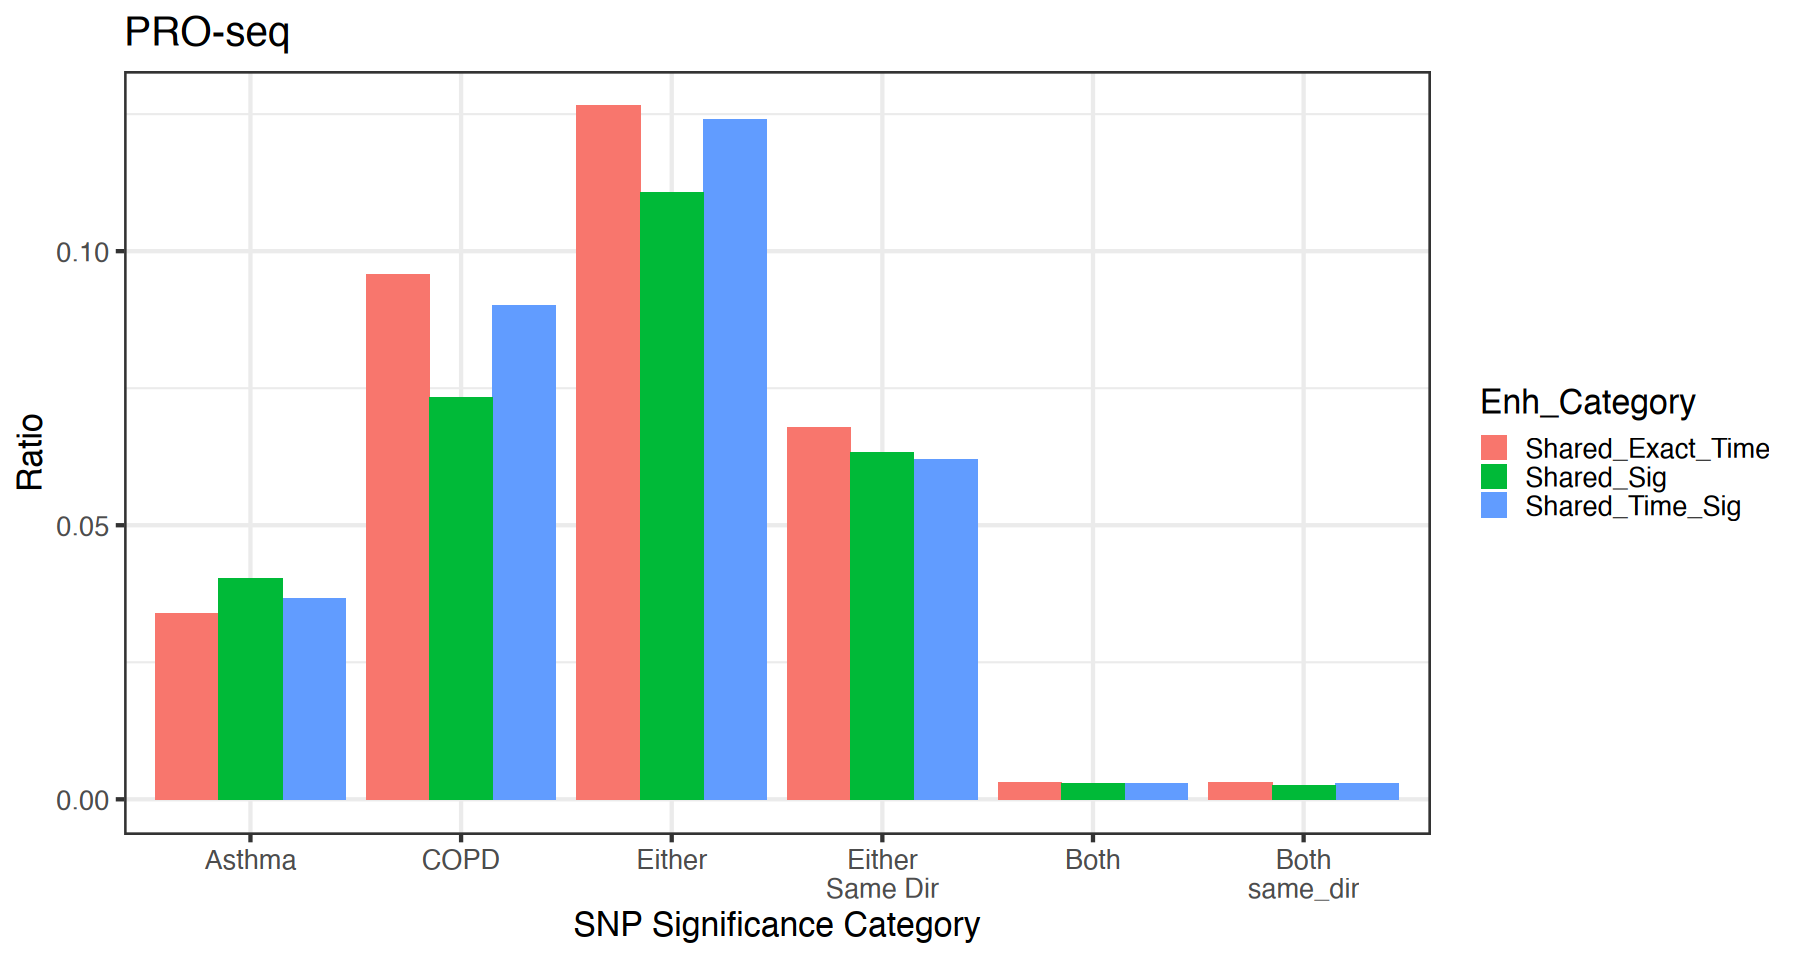

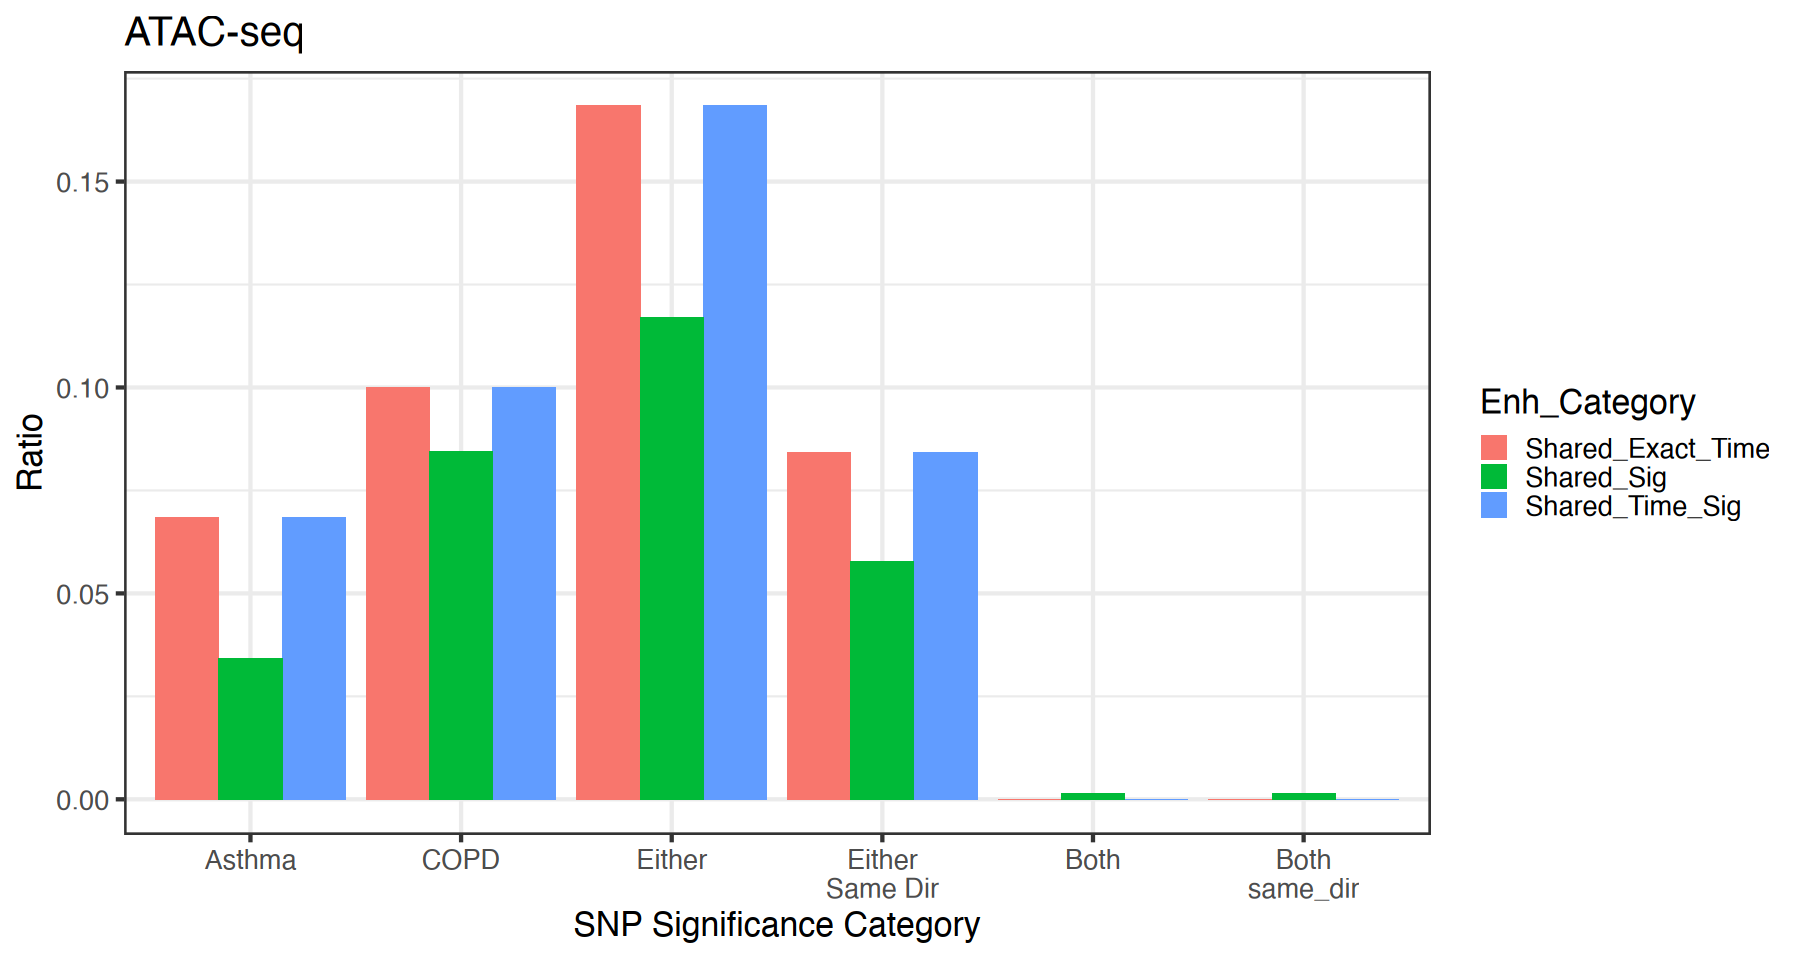

In [67]:
library(ggplot2)
options(repr.plot.width=15)
ggplot(SNP_ratio_df[SNP_ratio_df$Sig_Category != "Total",], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir", "Both", "Both\nsame_dir")), y=Ratio, fill=Enh_Category)) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + labs(x="SNP Significance Category") + ggtitle("PRO-seq")

ggplot(SNP_ratio_atac_df[SNP_ratio_atac_df$Sig_Category != "Total",], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir", "Both", "Both\nsame_dir")), y=Ratio, fill=Enh_Category)) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + labs(x="SNP Significance Category") + ggtitle("ATAC-seq")

In [12]:
SNP_time_ratio_df = get_number_SNPs(WSP_time_sig_nontss$Early, "WSP_Early")
SNP_time_ratio_df = rbind(get_number_SNPs(WSP_time_sig_nontss$Plat, "WSP_Plateau"), SNP_time_ratio_df)
SNP_time_ratio_df = rbind(get_number_SNPs(WSP_time_sig_nontss$Late, "WSP_Late"), SNP_time_ratio_df)

SNP_time_ratio_df = rbind(get_number_SNPs(UPM_time_sig_nontss$Early, "UPM_Early"), SNP_time_ratio_df)
SNP_time_ratio_df = rbind(get_number_SNPs(UPM_time_sig_nontss$Plat, "UPM_Plateau"), SNP_time_ratio_df)
SNP_time_ratio_df = rbind(get_number_SNPs(UPM_time_sig_nontss$Late, "UPM_Late"), SNP_time_ratio_df)

SNP_time_ratio_df = rbind(get_number_SNPs(shared_time_sig_nontss$Early, "Shared_Early"), SNP_time_ratio_df)
SNP_time_ratio_df = rbind(get_number_SNPs(shared_time_sig_nontss$Plat, "Shared_Plateau"), SNP_time_ratio_df)
SNP_time_ratio_df = rbind(get_number_SNPs(shared_time_sig_nontss$Late, "Shared_Late"), SNP_time_ratio_df)

SNP_time_ratio_df = rbind(get_number_SNPs(either_time_sig_nontss$Early, "Either_Early"), SNP_time_ratio_df)
SNP_time_ratio_df = rbind(get_number_SNPs(either_time_sig_nontss$Plat, "Either_Plateau"), SNP_time_ratio_df)
SNP_time_ratio_df = rbind(get_number_SNPs(either_time_sig_nontss$Late, "Either_Late"), SNP_time_ratio_df)

Warning sig list is long for WSP_Early



Warning sig list is long for WSP_Plateau

Warning sig list is long for WSP_Late

Warning sig list is long for UPM_Early

Warning sig list is long for UPM_Plateau

Warning sig list is long for UPM_Late

Warning sig list is long for Either_Early

Warning sig list is long for Either_Plateau

Warning sig list is long for Either_Late



In [13]:
SNP_time_ratio_atac_df = get_number_SNPs(WSP_time_sig_atac$Early, "WSP_Early")
SNP_time_ratio_atac_df = rbind(get_number_SNPs(WSP_time_sig_atac$Plat, "WSP_Plateau"), SNP_time_ratio_atac_df)
SNP_time_ratio_atac_df = rbind(get_number_SNPs(WSP_time_sig_atac$Late, "WSP_Late"), SNP_time_ratio_atac_df)

SNP_time_ratio_atac_df = rbind(get_number_SNPs(UPM_time_sig_atac$Early, "UPM_Early"), SNP_time_ratio_atac_df)
SNP_time_ratio_atac_df = rbind(get_number_SNPs(UPM_time_sig_atac$Plat, "UPM_Plateau"), SNP_time_ratio_atac_df)
SNP_time_ratio_atac_df = rbind(get_number_SNPs(UPM_time_sig_atac$Late, "UPM_Late"), SNP_time_ratio_atac_df)

SNP_time_ratio_atac_df = rbind(get_number_SNPs(shared_time_sig_atac$Early, "Shared_Early"), SNP_time_ratio_atac_df)
SNP_time_ratio_atac_df = rbind(get_number_SNPs(shared_time_sig_atac$Plat, "Shared_Plateau"), SNP_time_ratio_atac_df)
SNP_time_ratio_atac_df = rbind(get_number_SNPs(shared_time_sig_atac$Late, "Shared_Late"), SNP_time_ratio_atac_df)

SNP_time_ratio_atac_df = rbind(get_number_SNPs(either_time_sig_atac$Early, "Either_Early"), SNP_time_ratio_atac_df)
SNP_time_ratio_atac_df = rbind(get_number_SNPs(either_time_sig_atac$Plat, "Either_Plateau"), SNP_time_ratio_atac_df)
SNP_time_ratio_atac_df = rbind(get_number_SNPs(either_time_sig_atac$Late, "Either_Late"), SNP_time_ratio_atac_df)

Warning sig list is long for WSP_Plateau

Warning sig list is long for WSP_Late

Warning sig list is long for Either_Early

Warning sig list is long for Either_Plateau

Warning sig list is long for Either_Late



## See the enrichment of SNPs in each

SNP Categories:
* COPD_sig
* Asthma_sig
* Either_sig
* Both_sig
* Both_sig_same_dir

Enhancer Categories (x-axis):

In all timepoints:
* Shared (WSP and UPM)
* WSP
* UPM
* Either

Timepoints
* Early
* Plateau
* Late

In [14]:
SNP_time_ratio_df$Large_Scale_Cat <- "None"
SNP_time_ratio_df[grepl(SNP_time_ratio_df$Enh_Category, pattern="Shared"),]$Large_Scale_Cat <- "Shared"
SNP_time_ratio_df[grepl(SNP_time_ratio_df$Enh_Category, pattern="Either"),]$Large_Scale_Cat <- "Either"
SNP_time_ratio_df[grepl(SNP_time_ratio_df$Enh_Category, pattern="WSP"),]$Large_Scale_Cat <- "WSP"
SNP_time_ratio_df[grepl(SNP_time_ratio_df$Enh_Category, pattern="UPM"),]$Large_Scale_Cat <- "UPM"

SNP_time_ratio_df$Time_Cat <- str_split_fixed(SNP_time_ratio_df$Enh_Category, "_", 2)[,2]


SNP_time_ratio_atac_df$Large_Scale_Cat <- "None"
SNP_time_ratio_atac_df[grepl(SNP_time_ratio_atac_df$Enh_Category, pattern="Shared"),]$Large_Scale_Cat <- "Shared"
SNP_time_ratio_atac_df[grepl(SNP_time_ratio_atac_df$Enh_Category, pattern="Either"),]$Large_Scale_Cat <- "Either"
SNP_time_ratio_atac_df[grepl(SNP_time_ratio_atac_df$Enh_Category, pattern="WSP"),]$Large_Scale_Cat <- "WSP"
SNP_time_ratio_atac_df[grepl(SNP_time_ratio_atac_df$Enh_Category, pattern="UPM"),]$Large_Scale_Cat <- "UPM"

SNP_time_ratio_atac_df$Time_Cat <- str_split_fixed(SNP_time_ratio_atac_df$Enh_Category, "_", 2)[,2]

In [31]:
SNP_time_ratio_df[SNP_time_ratio_df$Sig_Category %in% c("Both", "Both\nsame_dir"),]

SNP_time_ratio_df[SNP_time_ratio_df$Sig_Category %in% c("Total"),]



,Enh_Category,Sig_Category,N,Ratio,N_Enh,Large_Scale_Cat,Time_Cat
,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<chr>
6,Shared_Late,Both,1,0.0096153846,287,Shared,Late
7,Shared_Late,Both same_dir,1,0.0096153846,287,Shared,Late
13,Shared_Plateau,Both,0,0.0000000000,235,Shared,Plateau
14,Shared_Plateau,Both same_dir,0,0.0000000000,235,Shared,Plateau
20,Shared_Early,Both,0,0.0000000000,280,Shared,Early
21,Shared_Early,Both same_dir,0,0.0000000000,280,Shared,Early
27,UPM_Late,Both,7,0.0043777361,6771,UPM,Late
28,UPM_Late,Both same_dir,5,0.0031269543,6771,UPM,Late
34,UPM_Plateau,Both,1,0.0016835017,2110,UPM,Plateau


,Enh_Category,Sig_Category,N,Ratio,N_Enh,Large_Scale_Cat,Time_Cat
,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<chr>
1,Shared_Late,Total,104,1.0000000,287,Shared,Late
8,Shared_Plateau,Total,78,1.0000000,235,Shared,Plateau
15,Shared_Early,Total,173,1.0000000,280,Shared,Early
22,UPM_Late,Total,1598,0.9993746,6771,UPM,Late
29,UPM_Plateau,Total,594,1.0000000,2110,UPM,Plateau
36,UPM_Early,Total,961,0.9989605,4121,UPM,Early
43,WSP_Late,Total,559,0.9982143,1346,WSP,Late
50,WSP_Plateau,Total,375,0.9973404,1224,WSP,Plateau
57,WSP_Early,Total,1550,0.9993553,3241,WSP,Early


In [32]:
SNP_time_ratio_atac_df[SNP_time_ratio_atac_df$Sig_Category %in% c("Both", "Both\nsame_dir"),]

SNP_time_ratio_atac_df[SNP_time_ratio_atac_df$Sig_Category %in% c("Total"),]

,Enh_Category,Sig_Category,N,Ratio,N_Enh,Large_Scale_Cat,Time_Cat
,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<chr>
6,Shared_Late,Both,0,0.000000000,77,Shared,Late
7,Shared_Late,Both same_dir,0,0.000000000,77,Shared,Late
13,Shared_Plateau,Both,0,0.000000000,396,Shared,Plateau
14,Shared_Plateau,Both same_dir,0,0.000000000,396,Shared,Plateau
20,Shared_Early,Both,0,0.000000000,175,Shared,Early
21,Shared_Early,Both same_dir,0,0.000000000,175,Shared,Early
27,UPM_Late,Both,0,0.000000000,240,UPM,Late
28,UPM_Late,Both same_dir,0,0.000000000,240,UPM,Late
34,UPM_Plateau,Both,0,0.000000000,966,UPM,Plateau


,Enh_Category,Sig_Category,N,Ratio,N_Enh,Large_Scale_Cat,Time_Cat
,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<chr>
1,Shared_Late,Total,15,1.0000000,77,Shared,Late
8,Shared_Plateau,Total,132,1.0000000,396,Shared,Plateau
15,Shared_Early,Total,43,1.0000000,175,Shared,Early
22,UPM_Late,Total,41,1.0000000,240,UPM,Late
29,UPM_Plateau,Total,266,1.0000000,966,UPM,Plateau
36,UPM_Early,Total,99,0.9900000,391,UPM,Early
43,WSP_Late,Total,190,0.9947644,1316,WSP,Late
50,WSP_Plateau,Total,346,1.0000000,1386,WSP,Plateau
57,WSP_Early,Total,194,0.9948718,959,WSP,Early


Warning message:
"package 'cowplot' was built under R version 4.4.1"


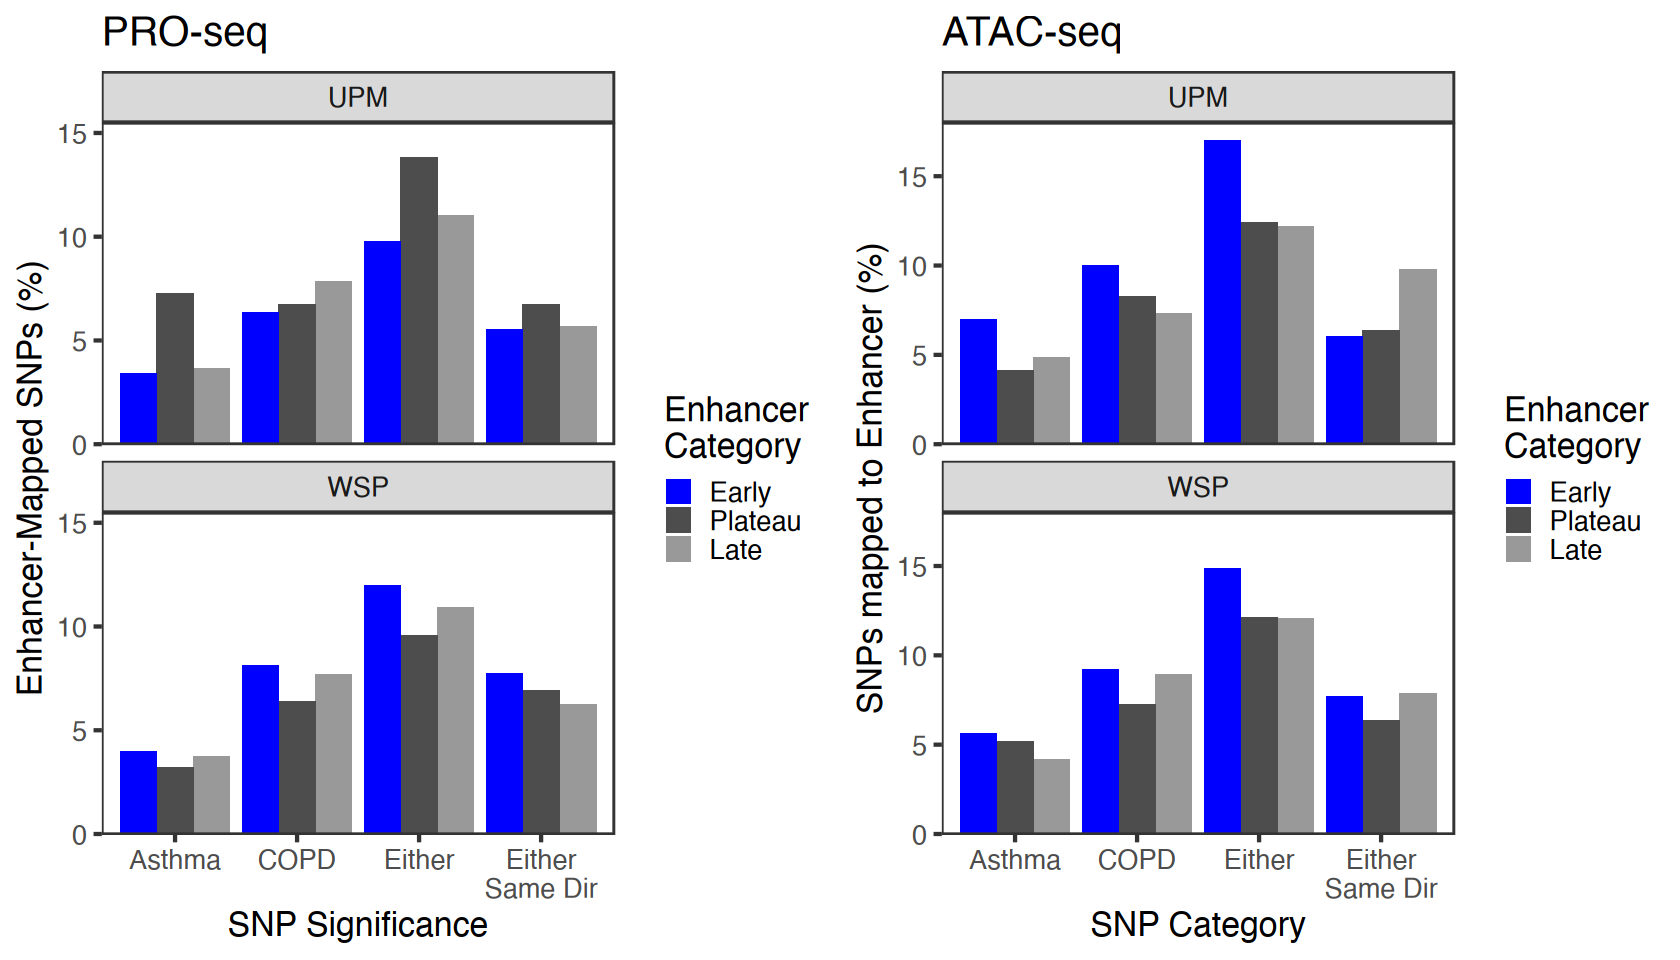

In [16]:
options(repr.plot.width=14, repr.plot.height=8)
color_dict=c("Early"="blue1", "Plateau"="grey30",  "Late"="grey60")
p1 <- ggplot(SNP_time_ratio_df[SNP_time_ratio_df$Large_Scale_Cat %in% c("UPM", "WSP") & SNP_time_ratio_df$Sig_Category != "Total" & SNP_time_ratio_df$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nSame Dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio*100, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("PRO-seq") +
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Enhancer-Mapped SNPs (%)") + scale_fill_manual(values=color_dict) + 
scale_y_continuous(limits = c(0, 15.5), expand=c(0, 0)) + theme(panel.grid = element_blank())

p2 <- ggplot(SNP_time_ratio_atac_df[SNP_time_ratio_atac_df$Large_Scale_Cat %in% c("UPM", "WSP") & SNP_time_ratio_atac_df$Sig_Category != "Total" & SNP_time_ratio_atac_df$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nSame Dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio*100, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("ATAC-seq") +
labs(fill="Enhancer\nCategory", x="SNP Category", y="SNPs mapped to Enhancer (%)") + scale_fill_manual(values=color_dict) + 
scale_y_continuous(limits = c(0, 18), expand=c(0, 0)) + theme(panel.grid = element_blank())
library(cowplot)
plot_grid(p1, p2, nrow=1)

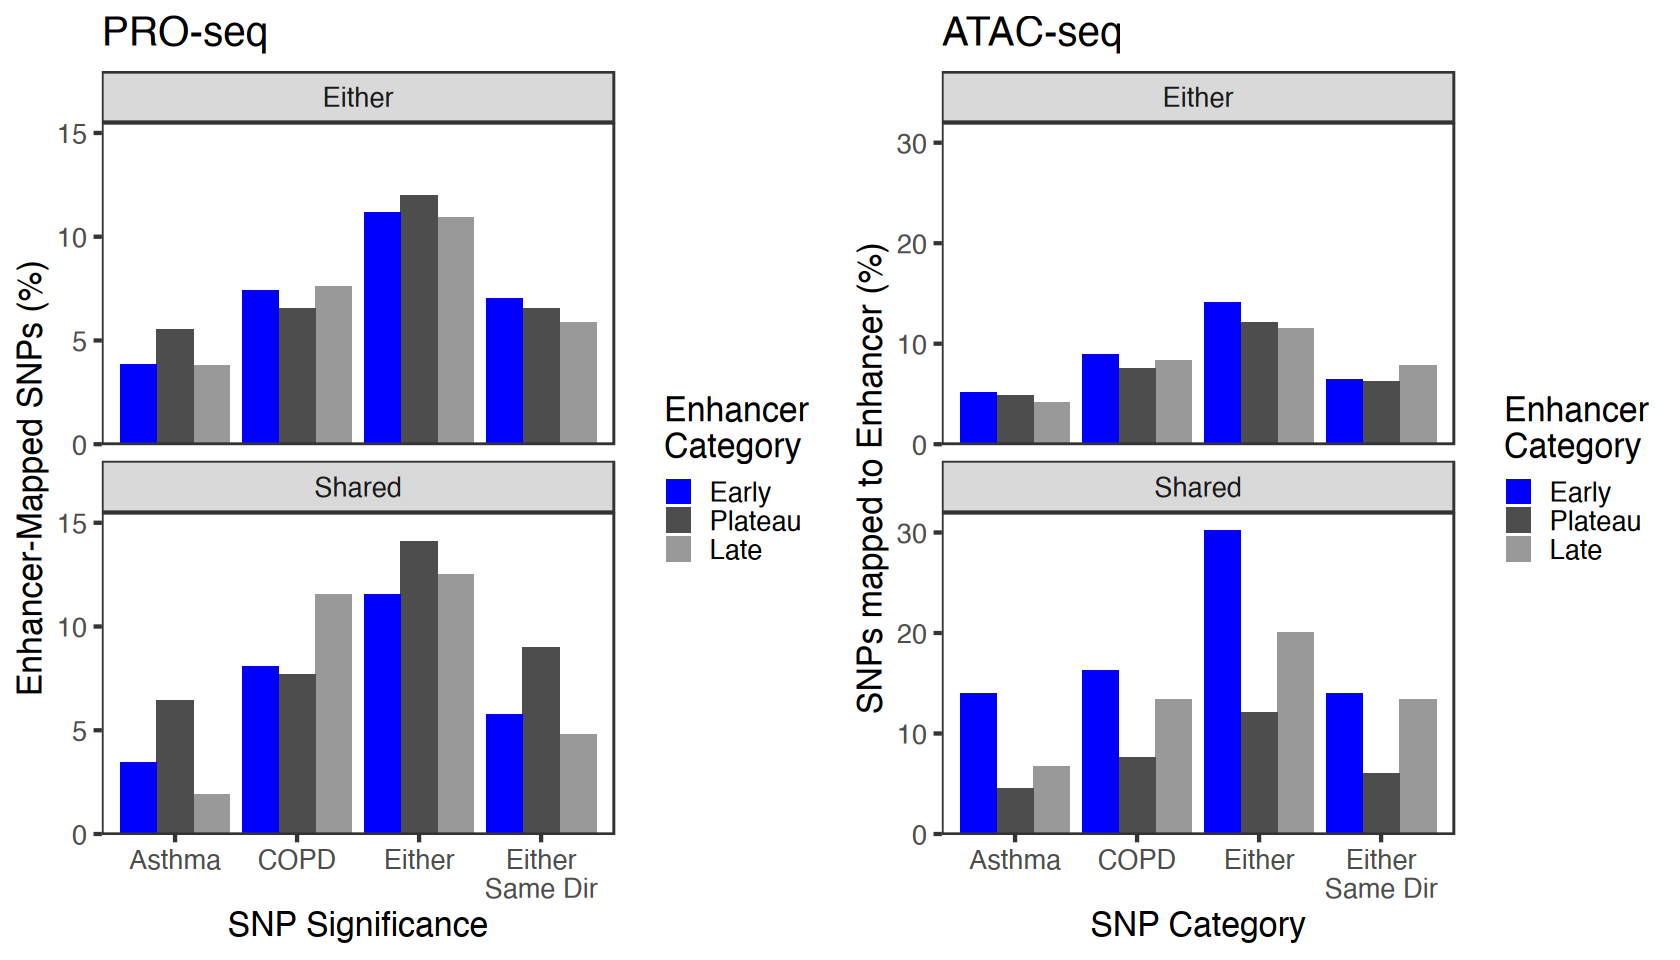

In [23]:
options(repr.plot.width=14, repr.plot.height=8)
p1 <- ggplot(SNP_time_ratio_df[SNP_time_ratio_df$Large_Scale_Cat %in% c("Shared", "Either") & SNP_time_ratio_df$Sig_Category != "Total" & SNP_time_ratio_df$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nSame Dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio*100, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("PRO-seq") +
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Enhancer-Mapped SNPs (%)") + scale_fill_manual(values=color_dict) + 
scale_y_continuous(limits = c(0, 15.5), expand=c(0, 0)) + theme(panel.grid = element_blank())

p2 <- ggplot(SNP_time_ratio_atac_df[SNP_time_ratio_atac_df$Large_Scale_Cat %in% c("Shared", "Either") & SNP_time_ratio_atac_df$Sig_Category != "Total" & SNP_time_ratio_atac_df$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nSame Dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio*100, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("ATAC-seq") +
labs(fill="Enhancer\nCategory", x="SNP Category", y="SNPs mapped to Enhancer (%)") + scale_fill_manual(values=color_dict) + 
scale_y_continuous(limits = c(0, 32), expand=c(0, 0)) + theme(panel.grid = element_blank())
library(cowplot)
plot_grid(p1, p2, nrow=1)

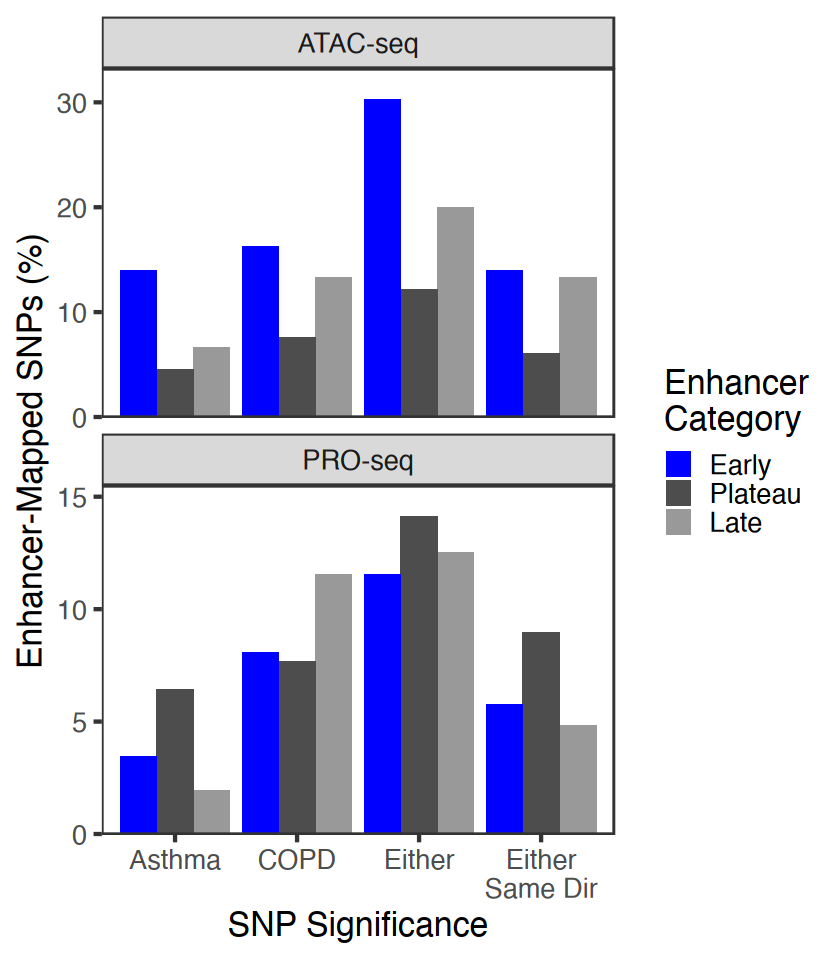

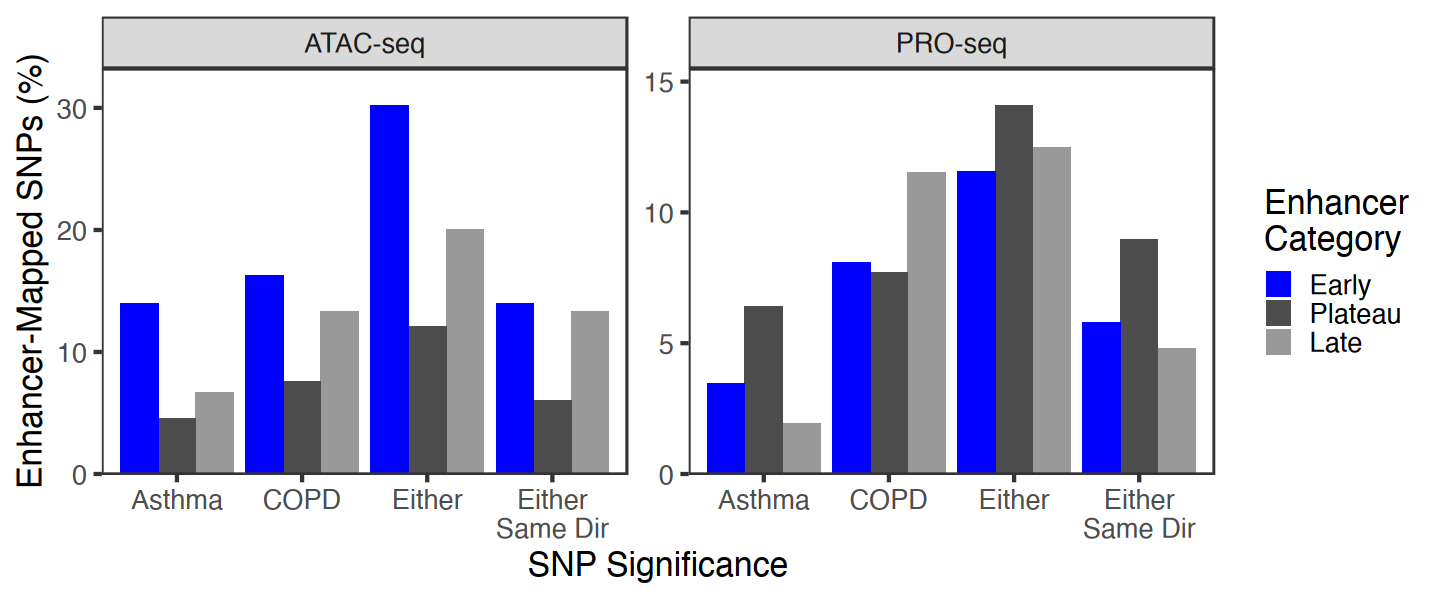

In [66]:
# do shared for plotting
SNP_time_ratio_atac_df$Assay <- "ATAC-seq"
SNP_time_ratio_df$Assay <- "PRO-seq"
SNP_time_ratio_df_comb <- rbind(SNP_time_ratio_atac_df, SNP_time_ratio_df)

options(repr.plot.width=7, repr.plot.height=8)
ggplot(SNP_time_ratio_df_comb[SNP_time_ratio_df_comb$Large_Scale_Cat == "Shared" & SNP_time_ratio_df_comb$Sig_Category != "Total" & SNP_time_ratio_df_comb$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nSame Dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio*100, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Assay, nrow=2, scale="free_y") +  
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Enhancer-Mapped SNPs (%)") + scale_fill_manual(values=color_dict) + 
scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
theme(panel.grid = element_blank())

options(repr.plot.width=12, repr.plot.height=5)
ggplot(SNP_time_ratio_df_comb[SNP_time_ratio_df_comb$Large_Scale_Cat == "Shared" & SNP_time_ratio_df_comb$Sig_Category != "Total" & SNP_time_ratio_df_comb$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nSame Dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio*100, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Assay, nrow=1, scale="free_y") +  
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Enhancer-Mapped SNPs (%)") + scale_fill_manual(values=color_dict) + 
scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
theme(panel.grid = element_blank())



Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`)."


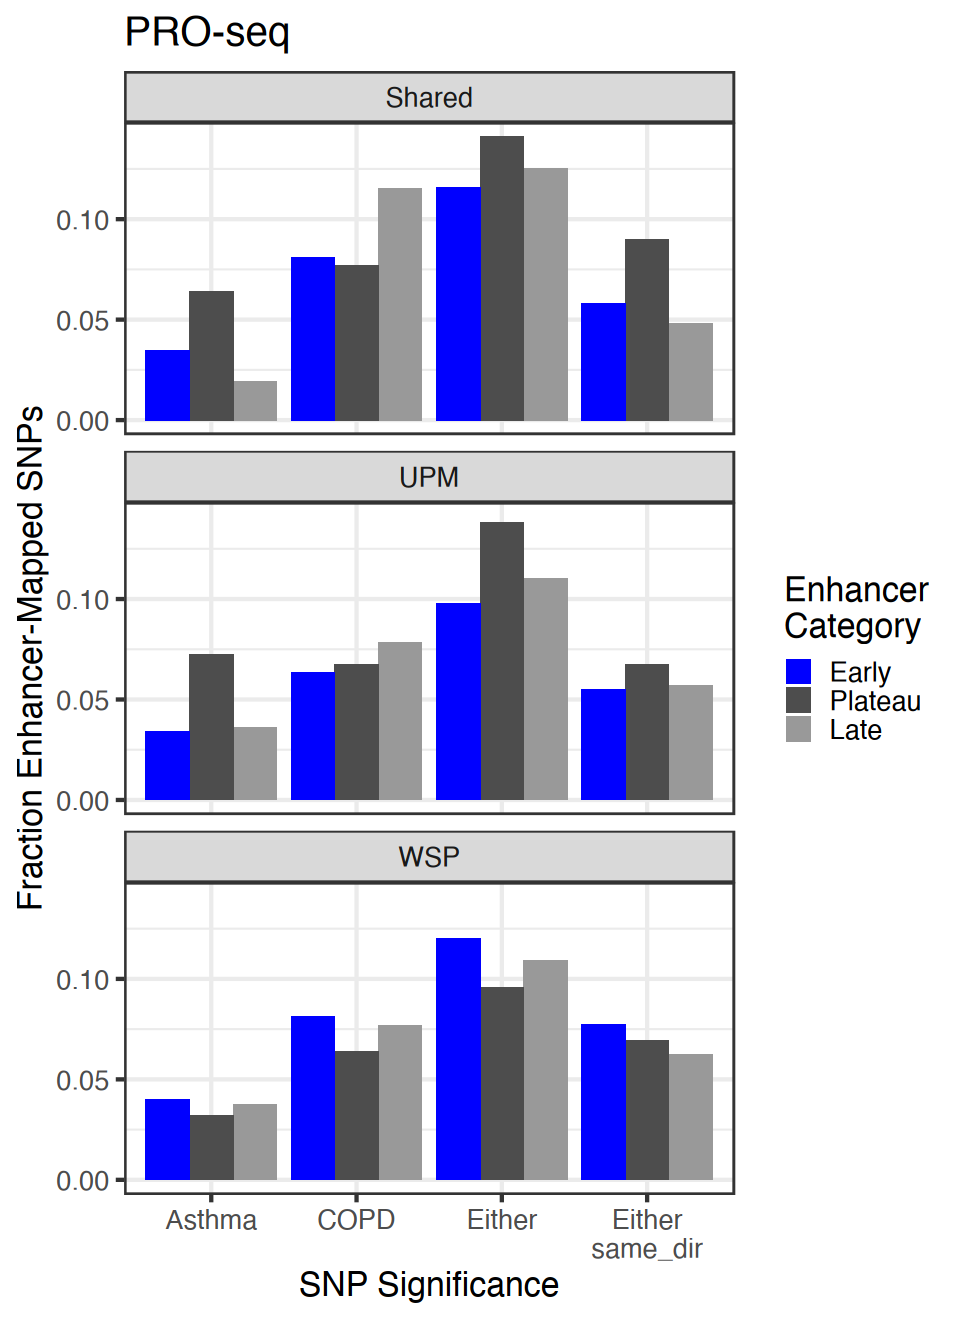

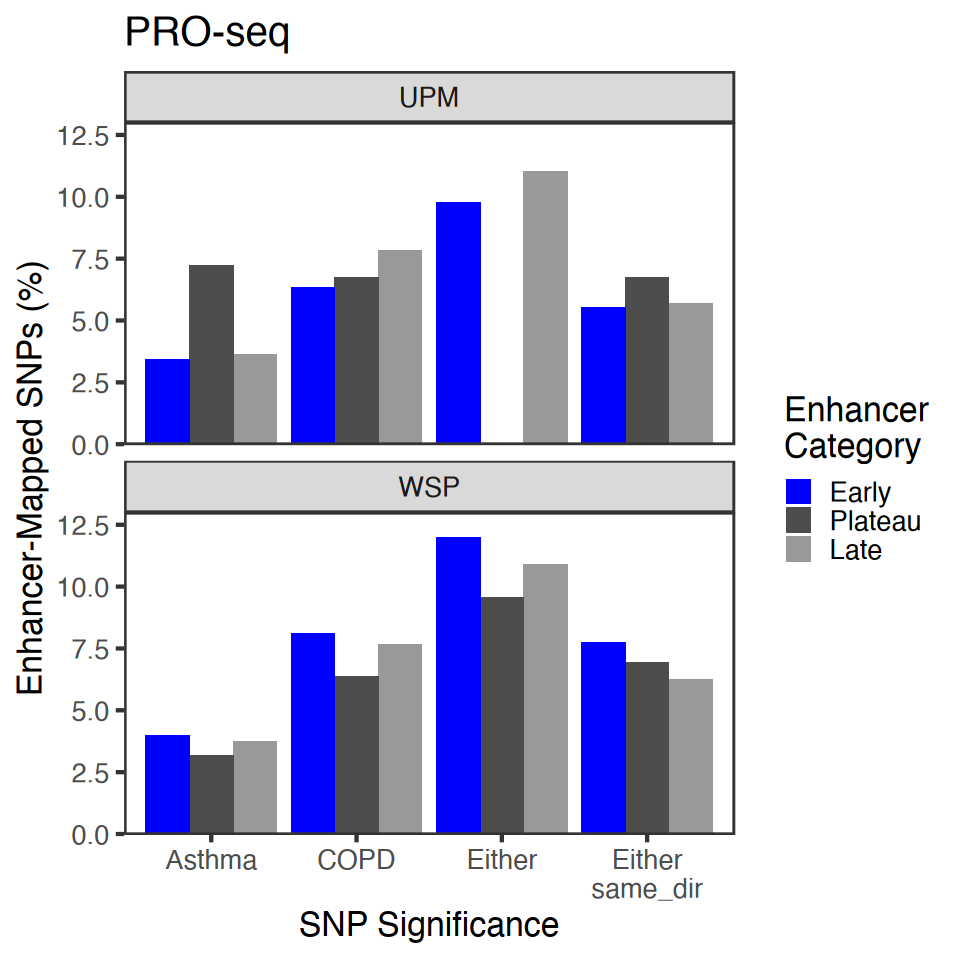

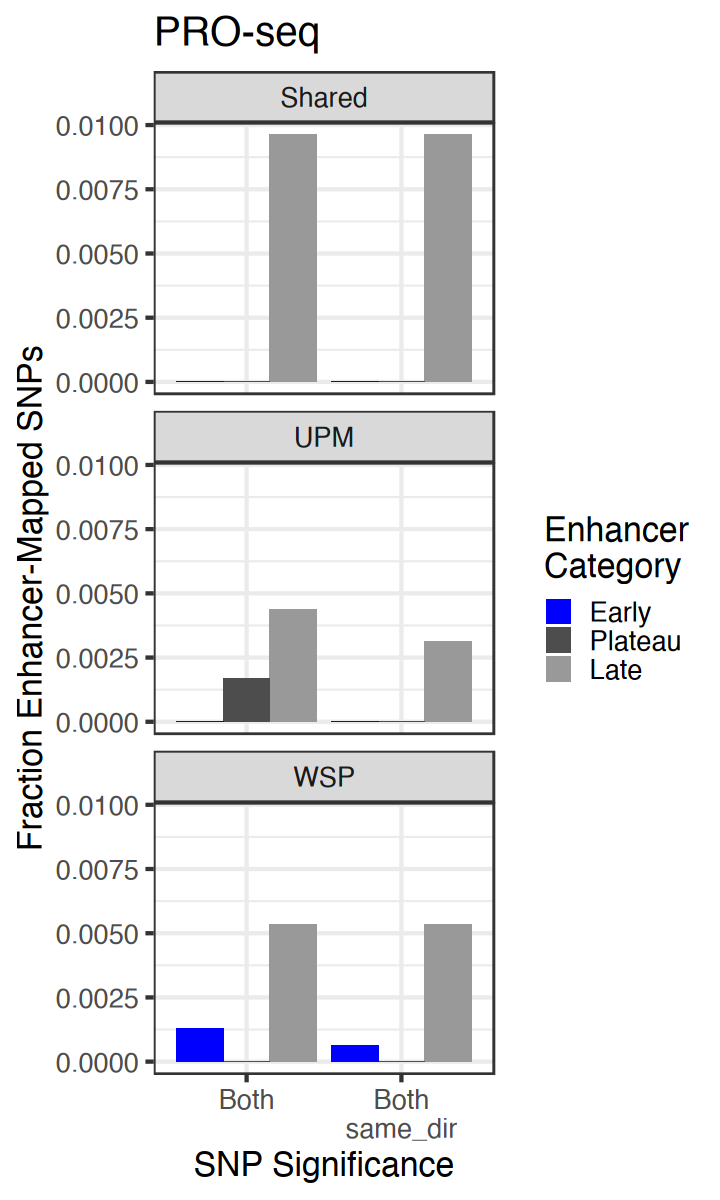

In [ ]:
options(repr.plot.width=8, repr.plot.height=11)
color_dict=c("Early"="blue1", "Plateau"="grey30",  "Late"="grey60")
ggplot(SNP_time_ratio_df[SNP_time_ratio_df$Sig_Category != "Total" & SNP_time_ratio_df$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nsame_dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("PRO-seq") +
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Fraction Enhancer-Mapped SNPs") + scale_fill_manual(values=color_dict)


options(repr.plot.width=6, repr.plot.height=10)
ggplot(SNP_time_ratio_df[SNP_time_ratio_df$Sig_Category != "Total" & SNP_time_ratio_df$Sig_Category %in% c("Both", "Both\nsame_dir"),], 
aes(x=factor(Sig_Category, c("Both", "Both\nsame_dir")), y=Ratio, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("PRO-seq") +
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Fraction Enhancer-Mapped SNPs") + scale_fill_manual(values=color_dict)

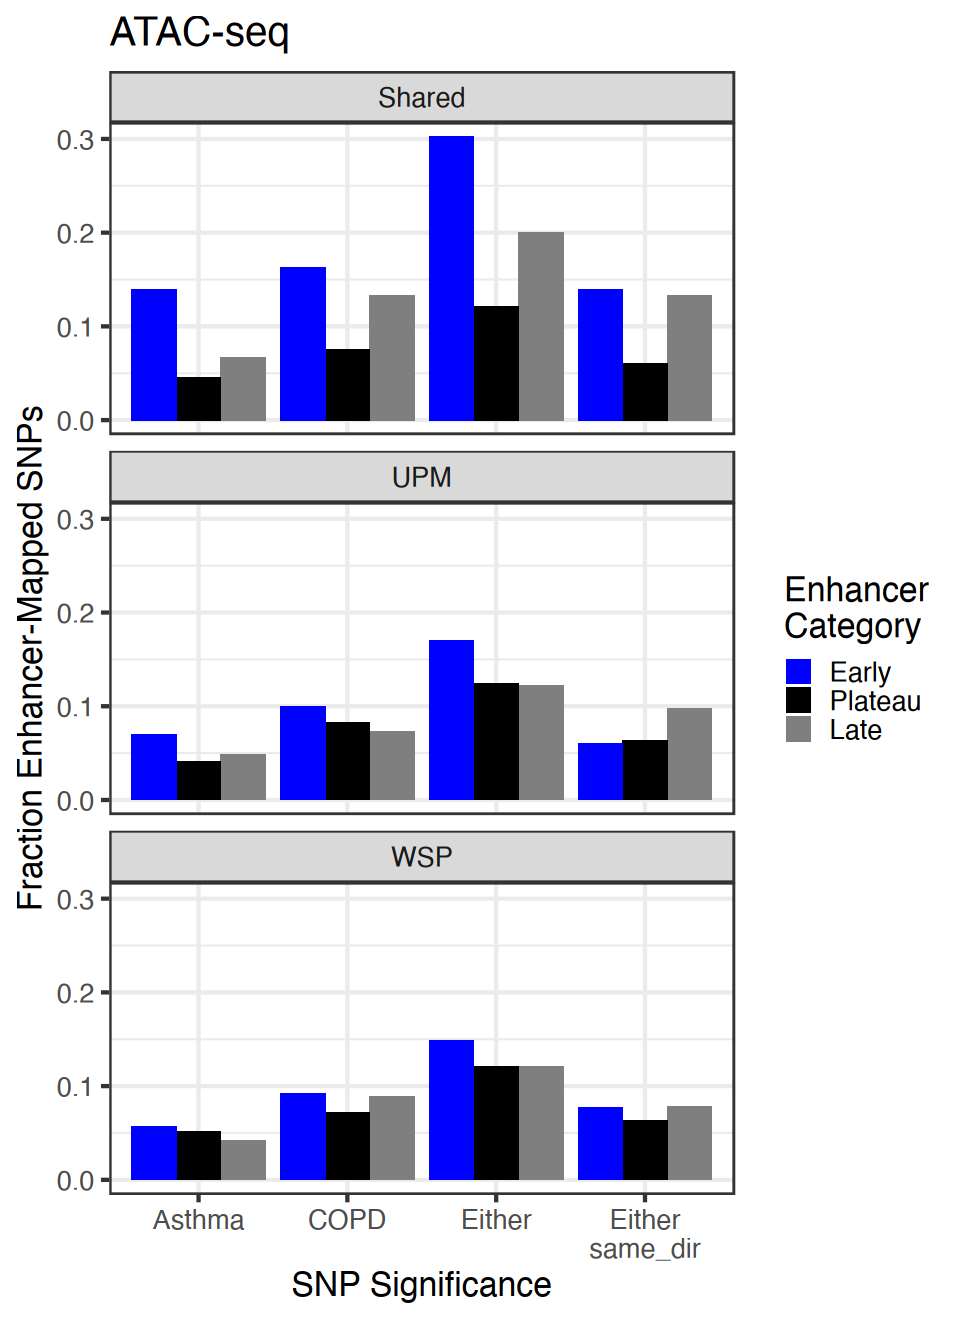

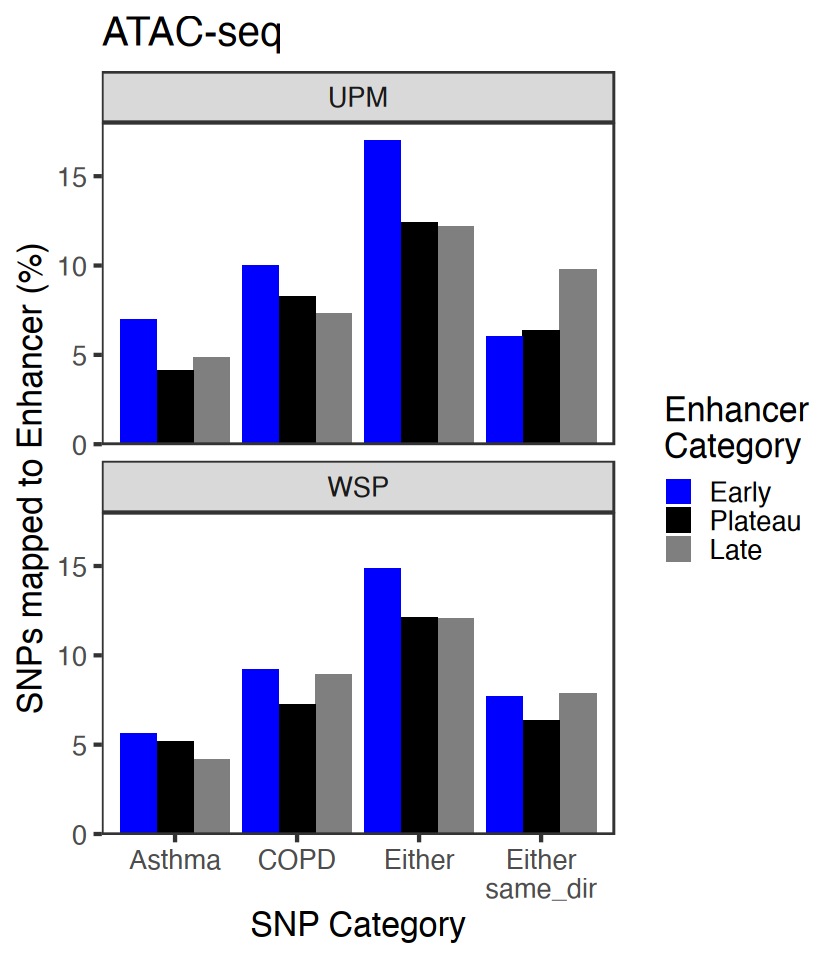

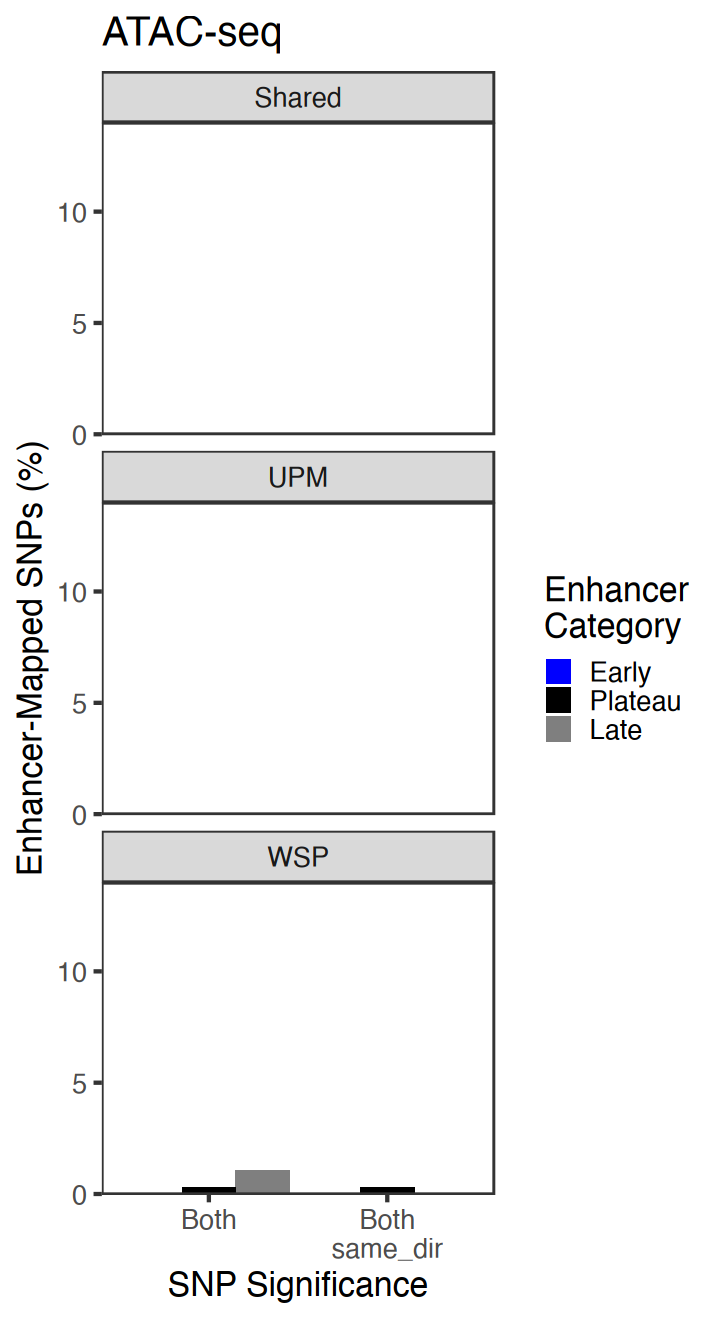

In [ ]:
options(repr.plot.width=8, repr.plot.height=11)
color_dict = c("Early"="c", "Plateau"="black", "Late"="grey50")
ggplot(SNP_time_ratio_atac_df[SNP_time_ratio_atac_df$Sig_Category != "Total" & SNP_time_ratio_atac_df$Sig_Category %in% c("Asthma", "COPD", "Either", "Either\nsame_dir"),], 
aes(x=factor(Sig_Category, c("Asthma", "COPD", "Either", "Either\nSame Dir")), y=Ratio, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("ATAC-seq") +
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Fraction Enhancer-Mapped SNPs") + scale_fill_manual(values=color_dict)



options(repr.plot.width=6, repr.plot.height=11)
ggplot(SNP_time_ratio_atac_df[SNP_time_ratio_atac_df$Sig_Category != "Total" & SNP_time_ratio_atac_df$Sig_Category %in% c("Both", "Both\nsame_dir"),], 
aes(x=factor(Sig_Category, c("Both", "Both\nsame_dir")), y=Ratio*100, 
fill=factor(Time_Cat, levels=c("Early", "Plateau", "Late")))) + 
geom_bar(stat="identity", pos="dodge") + theme_bw(base_size=20) + facet_wrap(~Large_Scale_Cat, nrow=3) + ggtitle("ATAC-seq") +
labs(fill="Enhancer\nCategory", x="SNP Significance", y="Enhancer-Mapped SNPs (%)") + scale_fill_manual(values=color_dict) + 
scale_y_continuous(limits = c(0, 14), expand=c(0, 0)) + theme(panel.grid = element_blank())

It seems there is no obvious enrichment of SNPs in non-transient responses. The Both and Both_same_dir categories are so strict that you only get 1-2 cases so that purely having higher numbers is more important.

## Graphing SNP presence frequencies from BAM files of Beas2B and smAEC cells

rs4919767: chr12:52873025 (orig G but now A)
* smAEC 36: 79% G, 21% A
* B2B: 45% G, 55%A 

rs4919766: chr12:52873026 (orig A but now G)
* smAEC 36: 78% A, 22% G
* B2B: 47% A, 53% G 

rs4919767/6: GA (Orig) vs AG (new)
* smAEC: GA: 77%  AG:  22%   AA: 0.5%    GG:  0.5%
* B2B: GA: 45%  AG: 55%

rs10876378: chr12:52873818 (orig A but now G)
* smAEC 36: 87% A, 13% G
* B2B: 81 A, 19% G

rs10876380: chr12:52873837 (orig G but now A)
* smAEC 36: 86% G, 14% A,
* B2B: 82% G, 18% A

In [50]:
SNP_df = data.table(
"SNP" = c("rs4919767", "rs4919767", "rs4919767", "rs4919767",
rep("rs4919766", 4), 
rep("rs4919767/6", 8), 
rep("rs10876378", 4), 
rep("rs10876380", 4)),
"Ref" = c("Ref", "Alt", "Ref", "Alt",
"Ref", "Alt", "Ref", "Alt",
"Ref", "Alt", "Ref", "Ref", "Ref", "Alt", "Ref", "Ref",
"Ref", "Alt", "Ref", "Alt",
"Ref", "Alt", "Ref", "Alt"),
"Allele" = c("G", "A", "G", "A",
"A", "G", "A", "G", 
"GA", "AG", "AA", "GG", "GA", "AG", "AA", "GG", 
"A", "G", "A", "G",
"G", "A", "G", "A"
),
"CT" = c("smAEC", "smAEC", "Beas2B", "Beas2B",
"smAEC", "smAEC", "Beas2B", "Beas2B", 
"smAEC", "smAEC", "smAEC", "smAEC", "Beas2B", "Beas2B", "Beas2B", "Beas2B", 
"smAEC", "smAEC", "Beas2B", "Beas2B", 
"smAEC", "smAEC", "Beas2B", "Beas2B"
),
"Perc" = c(79, 21, 45, 55, 
78, 22, 47, 53, 
77, 22, 0.5, 0.5, 45, 55, 0, 0,
87, 13, 81, 19, 
86, 14, 82, 18
))

SNP_df[1:4,]

SNP,Ref,Allele,CT,Perc
<chr>,<chr>,<chr>,<chr>,<dbl>
rs4919767,Ref,G,smAEC,79
rs4919767,Alt,A,smAEC,21
rs4919767,Ref,G,Beas2B,45
rs4919767,Alt,A,Beas2B,55


ADP      WSP      UPM 
"wheat2" "tomato"   "grey"

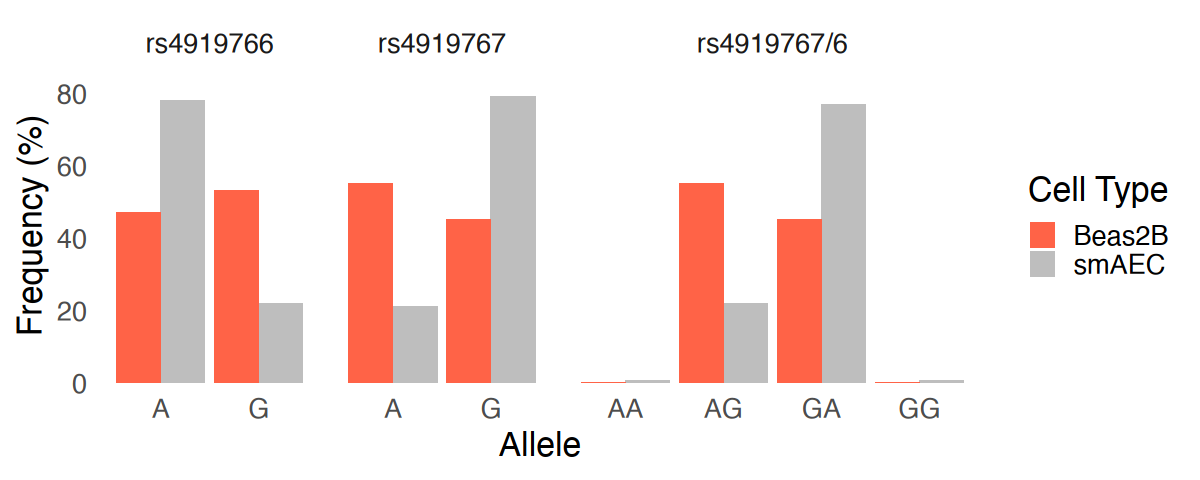

In [61]:
options(repr.plot.height=4, repr.plot.width=10)
ggplot(SNP_df[!SNP_df$SNP %in% c("rs10876378", "rs10876380"),], aes(x=Allele, y=Perc, fill=CT)) + 
geom_bar(stat="identity", position="dodge") + facet_wrap(~SNP, scale="free_x", space="free_x") + theme_minimal(base_size=20) + 
scale_fill_manual(values=c("Beas2B"="tomato", "smAEC"="grey")) + 
#scale_color_manual(values=c("Alt"="black", "Ref"="#0000")) +
theme(panel.grid=element_blank()) + scale_y_continuous(expand = expansion(mult = c(0, 0.1))) + labs(y="Frequency (%)", fill="Cell Type")
ggsave(filename="Freq_SNPs.pdf", height=4, width=10)
c("ADP"="wheat2", "WSP"="tomato", "UPM"="grey")

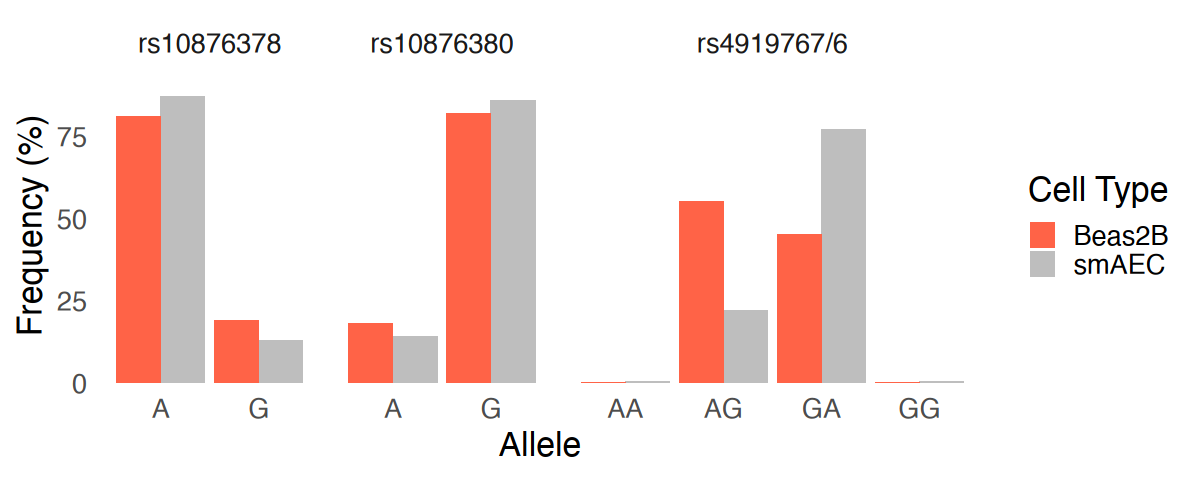

In [63]:
options(repr.plot.height=4, repr.plot.width=10)
ggplot(SNP_df[!SNP_df$SNP %in% c("rs4919766", "rs4919767"),], aes(x=Allele, y=Perc, fill=CT)) + 
geom_bar(stat="identity", position="dodge") + facet_wrap(~SNP, scale="free_x", space="free_x") + theme_minimal(base_size=20) + 
scale_fill_manual(values=c("Beas2B"="tomato", "smAEC"="grey")) + 
#scale_color_manual(values=c("Alt"="black", "Ref"="#0000")) +
theme(panel.grid=element_blank()) + scale_y_continuous(expand = expansion(mult = c(0, 0.1))) + labs(y="Frequency (%)", fill="Cell Type")
ggsave(filename="Freq_SNPs.pdf", height=4, width=10)

### Replotting SNP Annotations to look nicer for main Figure

ONE Sig SNP
	Category	Count	Percentage
0	Other Trait-associated	44	6.461087
1	ENCODE TF\nBinding Site	398	58.443465
2	Both significant\n+ same direction	15	2.202643
3	Both significant	18	2.643172
4	Same direction	389	57.121880

ALL SNPs
0	Other Trait-associated	44	0.713822
1	ENCODE TF\nBinding Site	398	6.456846
2	One significant	681	11.048021
3	Both significant\n+ same direction	15	0.243348
4	Both significant	18	0.292018
5	Same direction	3144	51.005840



In [97]:
df <- data.table(
	"Category"=c(rep(c("Other Trait\nassociated", "TF Binding\nSite", "C&A significant\nSame direction",
	"C&A\nsignificant", "C or A\nsignificant", "C&A Same\ndirection"), 2)), 
	"Count"=c(44, 398, 15, 18, 681, 3144,
		44, 398, 15, 18, 681, 389), 
	"Perc"=c(0.713822, 6.456846, 0.243348, 0.292018, 11.048021, 51.005840,
		6.461087, 58.443465, 2.202643, 2.643172, 100, 57.121889), 
	"LS_Category"=c(rep("All (N=6164)", 6), rep("C or A\nsignificant", 6))
)
df

Category,Count,Perc,LS_Category
<chr>,<dbl>,<dbl>,<chr>
Other Trait associated,44,0.713822,All (N=6164)
TF Binding Site,398,6.456846,All (N=6164)
C&A significant Same direction,15,0.243348,All (N=6164)
C&A significant,18,0.292018,All (N=6164)
C or A significant,681,11.048021,All (N=6164)
C&A Same direction,3144,51.005840,All (N=6164)
Other Trait associated,44,6.461087,C or A significant
TF Binding Site,398,58.443465,C or A significant
C&A significant Same direction,15,2.202643,C or A significant


Warning message in geom_text(aes(position = "dodge", label = paste0("N=", Count)), :
"Ignoring unknown aesthetics: position"


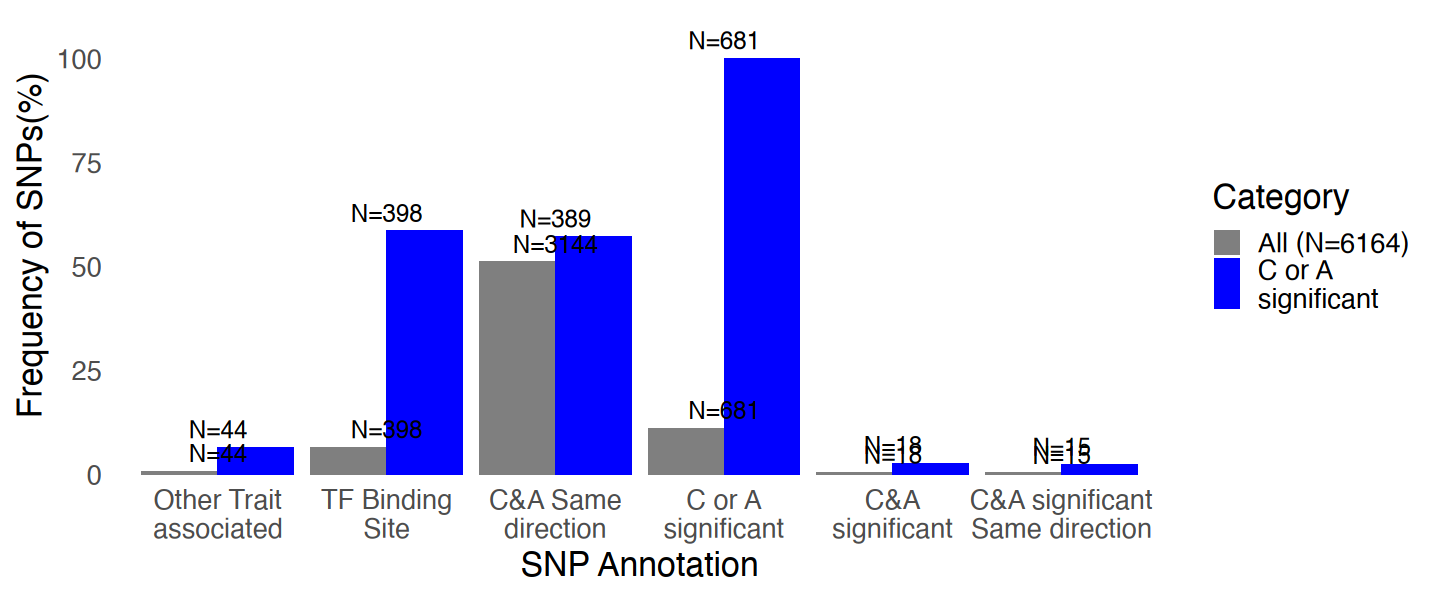

In [100]:
options(repr.plot.width=12, repr.plot.height=5)
ggplot(df, aes(x=factor(Category, levels=c("Other Trait\nassociated", "TF Binding\nSite", "C&A Same\ndirection", "C or A\nsignificant", "C&A\nsignificant", "C&A significant\nSame direction")), 
y=Perc, fill=LS_Category)) + geom_bar(stat="identity", position="dodge") + 
geom_text(aes(position="dodge", label = paste0("N=", Count)),
            vjust = -0.5, size = 5) +
theme_minimal(base_size=20) + labs(y="Frequency of SNPs(%)", x="SNP Annotation", fill="Category") + theme(panel.grid=element_blank()) + 
scale_y_continuous(expand = expansion(mult = c(0, 0.1))) + scale_fill_manual(values=c("All (N=6164)"="grey50", "C or A\nsignificant"="blue"))
ggsave("SNP_Annotation_Freq.pdf", height=5, width=12)